# **Import Library**

In [1]:
import numpy as np
import pandas as pd
import ssl
import holidays
import darts
from darts import TimeSeries
from darts.models import TFTModel
from darts.metrics import mae, rmse, mape, wmape
from darts.dataprocessing.transformers import Scaler

# **Load Data**

Mengambil data yang sudah disimpan dalam bentuk CSV yang terletak di GoogleSheets

In [2]:
print("Memuat data dari Google Sheets")
gsheet_url = "https://docs.google.com/spreadsheets/d/1c7sG94xHTxR98rTUIPkyKkOaSy7c-je8edwoHtFvWJg/gviz/tq?tqx=out:csv&sheet=csv_penjualan"

df_sales = pd.read_csv(gsheet_url, parse_dates = ['Tanggal'])
df_sales.set_index('Tanggal', inplace=True)
df_sales = df_sales.sort_index()

df_sales.head()

Memuat data dari Google Sheets


,Hari,Produksi Ayam,Produksi Udang,Produksi Keju,Produksi Telur,Produksi Sosis,Total Produksi,Terjual Ayam,Terjual Udang,Terjual Keju,Terjual Telur,Terjual Sosis,Total Terjual,Sisa
Tanggal,,,,,,,,,,,,,,
2026-01-01,Thursday,1227,213,146,146,146,1878,1161,202,138,138,138,1777,101
2026-01-02,Friday,1255,218,149,149,149,1920,1180,205,140,140,140,1805,115
2026-01-03,Saturday,1247,216,148,148,148,1907,1175,204,140,140,140,1799,108
2026-01-04,Sunday,1225,213,146,146,146,1876,1131,197,135,135,135,1733,143
2026-01-05,Monday,1298,226,155,155,155,1989,1229,214,147,147,147,1884,105


In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 216 entries, 2026-01-01 to 2026-08-04
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Hari            216 non-null    object
 1   Produksi Ayam   216 non-null    int64 
 2   Produksi Udang  216 non-null    int64 
 3   Produksi Keju   216 non-null    int64 
 4   Produksi Telur  216 non-null    int64 
 5   Produksi Sosis  216 non-null    int64 
 6   Total Produksi  216 non-null    int64 
 7   Terjual Ayam    216 non-null    int64 
 8   Terjual Udang   216 non-null    int64 
 9   Terjual Keju    216 non-null    int64 
 10  Terjual Telur   216 non-null    int64 
 11  Terjual Sosis   216 non-null    int64 
 12  Total Terjual   216 non-null    int64 
 13  Sisa            216 non-null    int64 
dtypes: int64(13), object(1)
memory usage: 25.3+ KB


In [4]:
print("Memuat data resep dari Google Sheets")

gsheet_resep = "https://docs.google.com/spreadsheets/d/1c7sG94xHTxR98rTUIPkyKkOaSy7c-je8edwoHtFvWJg/gviz/tq?tqx=out:csv&sheet=stok_bahan"
df_resep = pd.read_csv(gsheet_resep)
df_resep.head()

Memuat data resep dari Google Sheets


,Produksi,Ayam (kg),Udang (kg),Telur (butir),Sosis (pcs),Keju (kg),Tepung (kg),Mentega (kg),Mayonaise (kg),Tepung Panir (kg),Kentang Wortel (kg),Seledri (kg),Daun Bawang (kg),Bawang Merah (kg),Bawang Putih (kg)
0,1856,24.26,4.22,72,72.0,2.16,46.40,5.57,7.42,27.84,22.27,1.48,2.23,3.71,2.78
1,1912,24.96,4.34,74,74.0,2.23,47.80,5.74,7.65,28.68,22.94,1.53,2.29,3.82,2.87
2,1876,24.50,4.26,73,13.3,2.19,46.90,5.63,7.50,28.14,22.51,1.50,2.25,3.75,2.81
3,1989,25.96,4.52,78,78.0,2.32,49.73,5.97,7.96,29.83,23.87,1.59,2.39,3.98,2.98
4,4716,61.60,10.70,184,184.0,5.50,117.90,14.15,18.86,70.74,56.59,3.77,5.66,9.43,7.07


In [5]:
df_resep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Produksi             200 non-null    int64  
 1   Ayam (kg)            200 non-null    float64
 2   Udang (kg)           200 non-null    float64
 3   Telur (butir)        200 non-null    int64  
 4   Sosis (pcs)          200 non-null    float64
 5   Keju (kg)            200 non-null    float64
 6   Tepung (kg)          200 non-null    float64
 7   Mentega (kg)         200 non-null    float64
 8   Mayonaise (kg)       200 non-null    float64
 9   Tepung Panir (kg)    200 non-null    float64
 10  Kentang Wortel (kg)  200 non-null    float64
 11  Seledri (kg)         200 non-null    float64
 12  Daun Bawang (kg)     200 non-null    float64
 13  Bawang Merah (kg)    200 non-null    float64
 14  Bawang Putih (kg)    200 non-null    float64
dtypes: float64(13), int64(2)
memory usage: 2

#### Membuat Fitur Hari Libur Indonesia Secara Dinamis

In [6]:
print("Fitur Hari Libur Indonesia")

start_date = df_sales.index[0]
end_date = df_sales.index[-1] + pd.Timedelta(days=7)

ext_dates = pd.date_range(start= start_date, end= end_date, freq="D")

#mendefenisikan tanggal libur kostum
gholiday_url = "https://docs.google.com/spreadsheets/d/1c7sG94xHTxR98rTUIPkyKkOaSy7c-je8edwoHtFvWJg/gviz/tq?tqx=out:csv&sheet=hari_libur_custom"
df_holiday = pd.read_csv(gholiday_url, index_col='event')

df_holiday.info()

Fitur Hari Libur Indonesia
<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, Tahun Baru Masehi to Hari Natal
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   start   15 non-null     object
 1   end     15 non-null     object
 2   year    15 non-null     int64 
 3   status  15 non-null     object
dtypes: int64(1), object(3)
memory usage: 600.0+ bytes


In [7]:
#konversi tipe data start, end ke datetime
df_holiday["start"] = pd.to_datetime(df_holiday["start"])
df_holiday["end"] = pd.to_datetime(df_holiday["end"])
df_holiday.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, Tahun Baru Masehi to Hari Natal
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   start   15 non-null     datetime64[ns]
 1   end     15 non-null     datetime64[ns]
 2   year    15 non-null     int64         
 3   status  15 non-null     object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 600.0+ bytes


In [8]:
#hari libur nasional tetapi tetap beroperasi
workday_dates = []

for _, row in df_holiday[df_holiday["status"] == "workday"].iterrows():
    workday_dates.extend(
        pd.date_range(row["start"], row["end"])
    )

workday_dates = pd.DatetimeIndex(workday_dates).unique()

In [9]:
cust_hol_date = []
for _, row in df_holiday.iterrows():
    cust_hol_date.extend(
        pd.date_range(start=row["start"], end=row["end"])
    )
    
cust_hol_date = pd.DatetimeIndex(cust_hol_date).unique()

#Mengambil hari libur nasional resmi
id_holidays = holidays.country_holidays('ID', years=df_holiday['year'].unique().tolist())

#membangun dataframe covariate utama
df_covariates = pd.DataFrame(index=ext_dates)

#Pengecekan gabungan
def cek_status_libur(date):
    #tanggal libur nasional tetapi tetap beroperasi
    if date in workday_dates:
        return 0
        
    #cek libur nasional resmi
    if date in id_holidays:
        return 1

    #cek libur custom
    if date in cust_hol_date:
        return 1

    #cek libur rutin per sekali 2 minggu
    if date.day_of_week == 6 and date.isocalendar().week % 2 == 0:
        return 1
        
    return 0

In [10]:
#Mengisi kolom hari libur secara instan
df_covariates["hari_libur"] = df_covariates.index.map(cek_status_libur)

#konversi ke Darts TimeSeries
df_covariates["hari_minggu"] = df_covariates.index.dayofweek
df_covariates["bulan"] = df_covariates.index.month
df_covariates["tanggal"] = df_covariates.index.day

#menampilkan contoh data hari libur
print(df_covariates.loc["2026-01-01":"2026-06-30"])

            hari_libur  hari_minggu  bulan  tanggal
2026-01-01           0            3      1        1
2026-01-02           0            4      1        2
2026-01-03           0            5      1        3
2026-01-04           0            6      1        4
2026-01-05           0            0      1        5
...                ...          ...    ...      ...
2026-06-26           0            4      6       26
2026-06-27           0            5      6       27
2026-06-28           1            6      6       28
2026-06-29           1            0      6       29
2026-06-30           1            1      6       30

[181 rows x 4 columns]


# **Modeling menggunakan Temporal Fusion Transformer (TFT)**

1. Menentukan target dan covariates

In [11]:
#target utama: penjualan per menu
target_cols = [
    "Terjual Ayam",
    "Terjual Udang",
    "Terjual Keju",
    "Terjual Telur",
    "Terjual Sosis"
]

#Fitur masa lalu (past covariates} : sisa dan histori produksi sebelumnya
past_cov_cols =[
    "Sisa"
#    "Produksi Ayam",
#    "Produksi Udang",
#    "Produksi Keju",
#    "Produksi Telur",
#    "Produksi Sosis"
]

#Fitur masa depan (future covariates) : hari libur
future_cov_cols = ["hari_libur"]

2. Membuat Timeseries dan scaling

In [12]:
y_ts = TimeSeries.from_dataframe(
    df_sales, value_cols=target_cols, fill_missing_dates=True, freq="D")

past_conv_ts = TimeSeries.from_dataframe(
    df_sales, value_cols=past_cov_cols, fill_missing_dates=True, freq="D")

future_cov_ts = TimeSeries.from_dataframe(
    df_covariates, value_cols=future_cov_cols, fill_missing_dates=True, freq="D")

#Scaling
scaler_y = Scaler()
scaler_past = Scaler()
scaler_future = Scaler()

y_scaled =scaler_y.fit_transform(y_ts)
past_conv_scaled = scaler_past.fit_transform(past_conv_ts)
future_conv_scaled = scaler_future.fit_transform(future_cov_ts)

3. Training & BackTesting TFT Model menggunakan data 14 hari ke belakang untuk memprediksi 1 hari ke depan

In [13]:
#split data
model_tft = TFTModel(
    input_chunk_length=14,
    output_chunk_length=7,
    hidden_size=32,
    lstm_layers=1,
    num_attention_heads=2,
    dropout=0.1,
    batch_size=16,
    n_epochs=100,
    random_state=42
)

In [14]:
model_tft.fit(
    series=y_scaled,
    past_covariates=past_conv_scaled,
    future_covariates=future_conv_scaled
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │      0 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │  7.1 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │    896 │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │  8.4 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │  8.4 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │  2.8 K │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 64.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 64.1 K                                                                                               
Total estimated model params size (MB): 0.513                                                                      
Modules in train mode: 243                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\AXIOO\anaconda3\envs\myenv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\AXIOO\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=100` reached.


TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=1, num_attention_heads=2, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=14, output_chunk_length=7, batch_size=16, n_epochs=100, random_state=42)

In [15]:
#melakukan backtesting
backtest_scaled = model_tft.historical_forecasts(
    series = y_scaled,
    past_covariates=past_conv_scaled,
    future_covariates = future_conv_scaled,
    start = 0.7, #memulai test pada data ke 70%
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

In [16]:
#kembalikan hasil prediksi penjualan ke skala asli
pred_terjual = scaler_y.inverse_transform(backtest_scaled)

4. Evaluasi Metrik Prediksi Penjualan

In [17]:
def hitung_wmape_manual(y_true_ts, y_pred_ts):
    # Ambil array nilai asli dan prediksi
    actual = y_true_ts.values().flatten()
    pred = y_pred_ts.values().flatten()

    # Rumus WMAPE: (Sum Absolute Error / Sum Actual) * 100
    sum_actual = np.sum(actual)
    return 0.0 if sum_actual == 0 else (np.sum(np.abs(actual - pred)) / sum_actual)* 100

def calculate_metrics(y_ts, pred_terjual, target_cols):
    metrics_list =[]

    print("=== VERIFIKASI METRIK WMAPE MANUAL ===")
    for col in target_cols:
        y_true_single = y_ts[col].slice_intersect(pred_terjual)
        y_pred_single = pred_terjual[col]

        mae_val = mae(y_true_single, y_pred_single)
        rmse_val = rmse(y_true_single, y_pred_single)
        wmape_val = hitung_wmape_manual(y_true_single, y_pred_single)

        metrics_list.append({
            "Target": col,
            "MAE (pcs)": round(mae_val, 2),
            "RMSE": round(rmse_val, 2),
            "WMAPE Real (%)": round(wmape_val, 2)
        })

    return pd.DataFrame(metrics_list)

In [18]:
df_hasil = calculate_metrics(y_ts, pred_terjual, target_cols)
df_hasil

=== VERIFIKASI METRIK WMAPE MANUAL ===


,Target,MAE (pcs),RMSE,WMAPE Real (%)
0,Terjual Ayam,122.85,341.48,11.85
1,Terjual Udang,16.39,43.57,9.09
2,Terjual Keju,9.37,31.57,7.58
3,Terjual Telur,9.33,28.26,7.55
4,Terjual Sosis,13.08,37.82,10.59


5. Menghitung rekomendasi jumlah produksi

In [19]:
HARI_PREDIKSI = 7
#Menambhkah Safety Stock (Buffer) misalkan 5% dari estimasi penjualan agar tidak kehabisan stok saat permintaan melonjak
SAFETY_BUFFER =1.05 #tambahan 5%

future_pred_scaled = model_tft.predict(
    n=HARI_PREDIKSI,
    series=y_scaled,
    past_covariates=past_conv_scaled,
    future_covariates=future_conv_scaled
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

C:\Users\AXIOO\anaconda3\envs\myenv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\AXIOO\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [20]:
#transformasi kan ke skala asli, mengamankan nilai negatif
df_pred_future = scaler_y. inverse_transform(future_pred_scaled).to_dataframe().clip(lower=0)

In [21]:
df_rekom_produksi = (df_pred_future * SAFETY_BUFFER).round().astype(int)

#Mengganti nama kolom dari "Terjual menjadi "RekomendasinProduksi"
df_rekom_produksi.columns = [
    col.replace("Terjual", "Rekomendasi Produksi")
    for col in df_rekom_produksi.columns
]

In [22]:
#Mengambil nilai hari libur dari df_covariates berdasarkan Tangal (index)
df_rekom_produksi["Status Libur"] = df_rekom_produksi.index.map(
    df_covariates["hari_libur"]
).map({1: "Libur", 0: "Kerja"})


In [23]:
#Nilai rekomendasi menjadi 0 jika tanggal tersebut TUTUP
is_tutup = df_rekom_produksi["Status Libur"] == "Libur"
df_rekom_produksi.loc[is_tutup, df_rekom_produksi.columns[:-1]] = 0

In [24]:
print("\n=== SAMPLE REKOMENDASI PRODUKSI (7 HARI TERAKHIR) ===")
print(df_rekom_produksi.head(7))


=== SAMPLE REKOMENDASI PRODUKSI (7 HARI TERAKHIR) ===
            Rekomendasi Produksi Ayam  Rekomendasi Produksi Udang  \
Tanggal                                                             
2026-08-05                       1166                         217   
2026-08-06                       1263                         222   
2026-08-07                       1209                         213   
2026-08-08                       1225                         213   
2026-08-09                          0                           0   
2026-08-10                       1131                         215   
2026-08-11                       3108                         215   

            Rekomendasi Produksi Keju  Rekomendasi Produksi Telur  \
Tanggal                                                             
2026-08-05                        152                         138   
2026-08-06                        143                         148   
2026-08-07                        147          

In [25]:
import joblib

#Menyimpan model dengan fit 100% data
model_tft.save("tft_model_produksi.pt")

#menyimpan ketiga scaler dalam 1 file .pkl
scaler_dict = {
    "scaler_y": scaler_y,
    "scaler_past": scaler_past,
    "scaler_future": scaler_future,
}

joblib.dump(scaler_dict, "scaler_produksi_final.pkl")

['scaler_produksi_final.pkl']

# **Rekomendasi Bahan Baku**

In [26]:
#Hitung rasio penggunaan bahan baku per unit produksi
kolom_bahan = [col for col in df_resep.columns if col != 'Produksi']

#Hitung rasio pemakaian (Bahan / Total Produksi)
df_rasio = df_resep[kolom_bahan].div(df_resep['Produksi'], axis=0)

#Rata-rata rasio penggunaan bahan baku
rasio_bahan_mean = df_rasio.mean()

In [27]:
#Hitung total rekomendasi produk harian
#mengambil kolom rekomendasi produksi saja
kol_rekom_menu = [col for col in df_rekom_produksi.columns if col !='Status Libur']

#Total Rekomendasi produksi per hari (Penjumlahan seluruh meni per tanggal)
tot_rekom_harian = df_rekom_produksi[kol_rekom_menu].sum(axis=1)

In [28]:
#Kalikan dengan rasio untuk mendapatkan rekomendasi stok bahan
#membuat dataframe rekomendasi stok bahan baku
df_rekom_bahan = pd.DataFrame(index=df_rekom_produksi.index)

for bahan, rasio in rasio_bahan_mean.items():
    #Kebutuhan bahan = total rekomendasi produksi harian * rasio bahan
    df_rekom_bahan[f"Stok {bahan}"] = (tot_rekom_harian  * rasio).round(2)

#Set nilai 0 untuk hari libur/ tuutp
is_tutup = df_rekom_produksi["Status Libur"] == "Libur"
df_rekom_bahan.loc[is_tutup, :] = 0

#Menambhakan informasi status libur
df_rekom_bahan["Status Libur"] = df_rekom_produksi["Status Libur"]

In [29]:
#Menampikna hasil rekomendasi stok bahan baku
print("\nRekomendasi Stok Bahan Baku Harian (7 Hari kedepan)")
print(df_rekom_bahan.head(7))


Rekomendasi Stok Bahan Baku Harian (7 Hari kedepan)
            Stok Ayam (kg)  Stok Udang (kg)  Stok Telur (butir)  \
Tanggal                                                           
2026-08-05           23.78             4.13               70.88   
2026-08-06           25.15             4.37               74.97   
2026-08-07           24.36             4.23               72.60   
2026-08-08           24.55             4.27               73.18   
2026-08-09            0.00             0.00                0.00   
2026-08-10           23.44             4.08               69.87   
2026-08-11           49.17             8.55              146.55   

            Stok Sosis (pcs)  Stok Keju (kg)  Stok Tepung (kg)  \
Tanggal                                                          
2026-08-05             70.59            2.13             45.53   
2026-08-06             74.66            2.25             48.15   
2026-08-07             72.30            2.18             46.63   
2026-08-08   

C:\Users\AXIOO\AppData\Local\Temp\ipykernel_13572\1709522125.py:94: UserWarning: Glyph 129375 (\N{DUMPLING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\AXIOO\AppData\Local\Temp\ipykernel_13572\1709522125.py:94: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\AXIOO\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129375 (\N{DUMPLING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\AXIOO\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


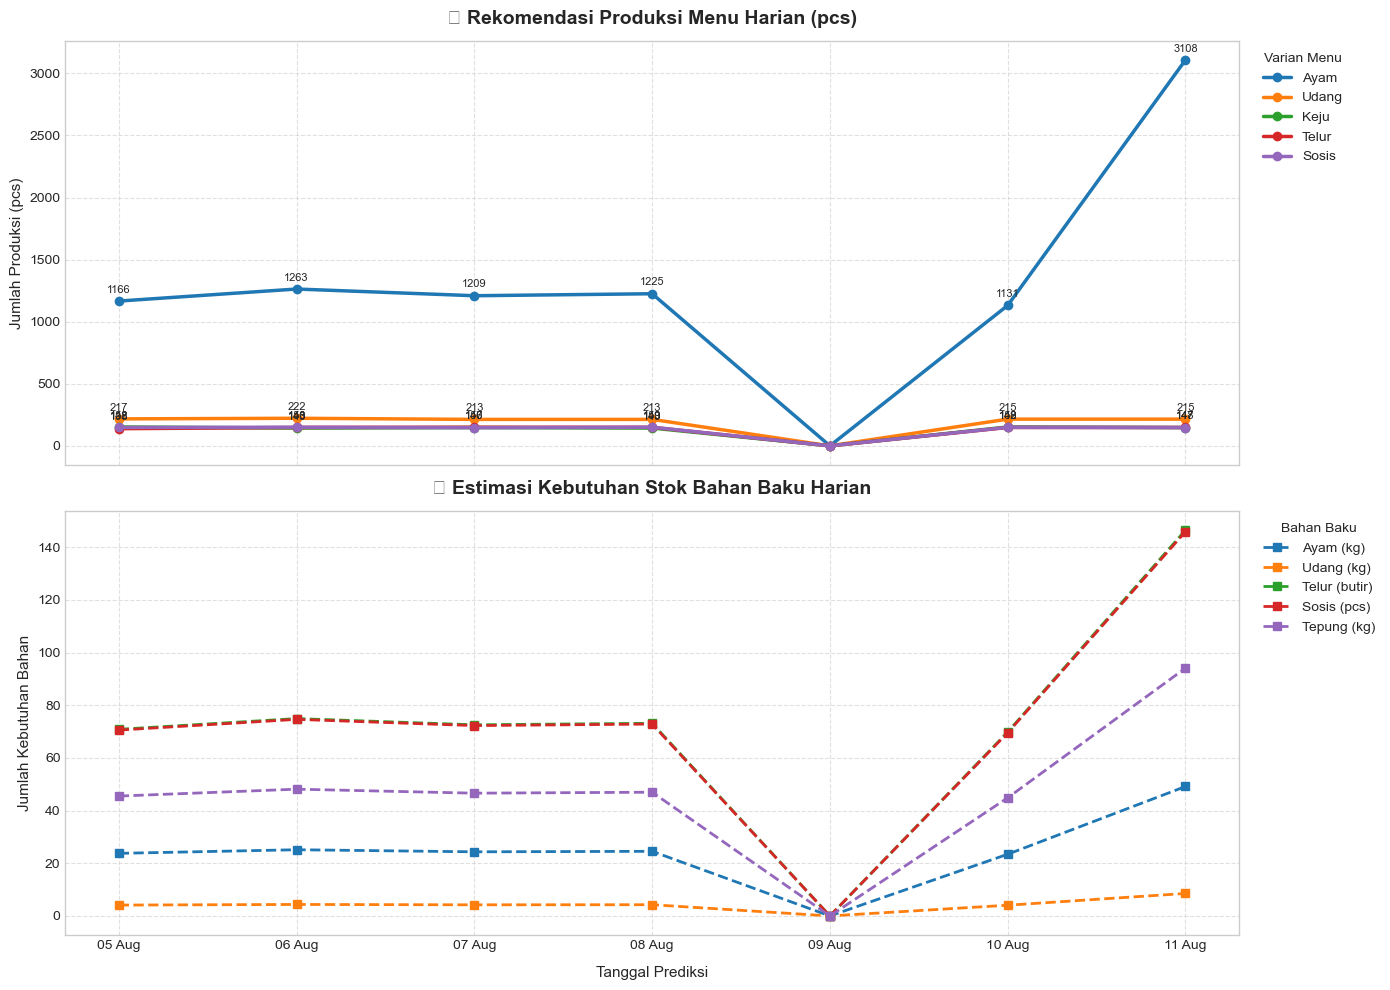

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style tampilan visualisasi agar bersih dan modern
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("tab10")

# =====================================================================
# 1. VISUALISASI REKOMENDASI PRODUKSI MENU (PCS)
# =====================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Ambil kolom menu saja (abaikan 'Status Libur')
kolom_menu = [col for col in df_rekom_produksi.columns if col != 'Status Libur']

# Plot Line Chart untuk Setiap Menu
for col in kolom_menu:
    label_clean = col.replace("Rekomendasi Produksi ", "")
    axes[0].plot(
        df_rekom_produksi.index.strftime('%d %b'), 
        df_rekom_produksi[col], 
        marker='o', 
        linewidth=2.5, 
        label=label_clean
    )

axes[0].set_title('🥟 Rekomendasi Produksi Menu Harian (pcs)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Jumlah Produksi (pcs)', fontsize=11)
axes[0].legend(title="Varian Menu", bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Tambahkan Annotasi Angka pada setiap titik
for col in kolom_menu:
    for idx, val in enumerate(df_rekom_produksi[col]):
        if val > 0: # Hanya tampilkan jika buka
            axes[0].annotate(
                f"{val}", 
                (idx, val), 
                textcoords="offset points", 
                xytext=(0, 6), 
                ha='center', 
                fontsize=8
            )


# =====================================================================
# 2. VISUALISASI REKOMENDASI STOK BAHAN BAKU UTAMA
# =====================================================================
# Pilih 5 bahan baku utama untuk ditampilkan di grafik
bahan_utama = [col for col in df_rekom_bahan.columns if col in [
    'Stok Ayam (kg)', 'Stok Udang (kg)', 'Stok Telur (butir)', 
    'Stok Tepung (kg)', 'Stok Sosis (pcs)'
]]

# Jika nama kolom berbeda, otomatis mengambil 5 kolom pertama
if len(bahan_utama) == 0:
    bahan_utama = [col for col in df_rekom_bahan.columns if col != 'Status Libur'][:5]

# Plot Bar Chart / Line Chart Bahan Baku
for col in bahan_utama:
    label_clean = col.replace("Stok ", "")
    axes[1].plot(
        df_rekom_bahan.index.strftime('%d %b'), 
        df_rekom_bahan[col], 
        marker='s', 
        linestyle='--', 
        linewidth=2, 
        label=label_clean
    )

axes[1].set_title('🛒 Estimasi Kebutuhan Stok Bahan Baku Harian', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Tanggal Prediksi', fontsize=11, labelpad=10)
axes[1].set_ylabel('Jumlah Kebutuhan Bahan', fontsize=11)
axes[1].legend(title="Bahan Baku", bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)


# =====================================================================
# 3. HIGHLIGHT HARI LIBUR / TUTUP
# =====================================================================
for idx, (tgl, row) in enumerate(df_rekom_produksi.iterrows()):
    if row['Status Libur'] == 'Libur/Tutup':
        # Beri warna shading abu-abu pada tanggal libur
        axes[0].axvspan(idx - 0.2, idx + 0.2, color='red', alpha=0.15)
        axes[1].axvspan(idx - 0.2, idx + 0.2, color='red', alpha=0.15)
        
        # Tambahkan teks "LIBUR"
        axes[0].text(idx, axes[0].get_ylim()[1]*0.5, 'TUTUP / LIBUR', 
                     color='red', fontweight='bold', ha='center', va='center', rotation=90)
        axes[1].text(idx, axes[1].get_ylim()[1]*0.5, 'TUTUP / LIBUR', 
                     color='red', fontweight='bold', ha='center', va='center', rotation=90)

plt.tight_layout()
plt.show()

In [31]:
df = pd.concat([df_rekom_bahan, df_rekom_produksi])
df.head()

,Stok Ayam (kg),Stok Udang (kg),Stok Telur (butir),Stok Sosis (pcs),Stok Keju (kg),Stok Tepung (kg),Stok Mentega (kg),Stok Mayonaise (kg),Stok Tepung Panir (kg),Stok Kentang Wortel (kg),Stok Seledri (kg),Stok Daun Bawang (kg),Stok Bawang Merah (kg),Stok Bawang Putih (kg),Status Libur,Rekomendasi Produksi Ayam,Rekomendasi Produksi Udang,Rekomendasi Produksi Keju,Rekomendasi Produksi Telur,Rekomendasi Produksi Sosis
Tanggal,,,,,,,,,,,,,,,,,,,,
2026-08-05,23.78,4.13,70.88,70.59,2.13,45.53,5.46,7.28,27.31,21.85,1.46,2.18,3.64,2.73,Kerja,NaN,NaN,NaN,NaN,NaN
2026-08-06,25.15,4.37,74.97,74.66,2.25,48.15,5.78,7.70,28.89,23.11,1.54,2.31,3.85,2.89,Kerja,NaN,NaN,NaN,NaN,NaN
2026-08-07,24.36,4.23,72.60,72.30,2.18,46.63,5.60,7.46,27.97,22.38,1.49,2.24,3.73,2.80,Kerja,NaN,NaN,NaN,NaN,NaN
2026-08-08,24.55,4.27,73.18,72.88,2.19,47.00,5.64,7.52,28.20,22.56,1.50,2.26,3.76,2.82,Kerja,NaN,NaN,NaN,NaN,NaN
2026-08-09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Libur,NaN,NaN,NaN,NaN,NaN


In [32]:
df_total = pd.concat([df_rekom_bahan, df_rekom_produksi.drop(columns=['Status Libur'])], axis=1)

# Tampilkan hasil
df_total.head()

,Stok Ayam (kg),Stok Udang (kg),Stok Telur (butir),Stok Sosis (pcs),Stok Keju (kg),Stok Tepung (kg),Stok Mentega (kg),Stok Mayonaise (kg),Stok Tepung Panir (kg),Stok Kentang Wortel (kg),Stok Seledri (kg),Stok Daun Bawang (kg),Stok Bawang Merah (kg),Stok Bawang Putih (kg),Status Libur,Rekomendasi Produksi Ayam,Rekomendasi Produksi Udang,Rekomendasi Produksi Keju,Rekomendasi Produksi Telur,Rekomendasi Produksi Sosis
Tanggal,,,,,,,,,,,,,,,,,,,,
2026-08-05,23.78,4.13,70.88,70.59,2.13,45.53,5.46,7.28,27.31,21.85,1.46,2.18,3.64,2.73,Kerja,1166,217,152,138,148
2026-08-06,25.15,4.37,74.97,74.66,2.25,48.15,5.78,7.70,28.89,23.11,1.54,2.31,3.85,2.89,Kerja,1263,222,143,148,150
2026-08-07,24.36,4.23,72.60,72.30,2.18,46.63,5.60,7.46,27.97,22.38,1.49,2.24,3.73,2.80,Kerja,1209,213,147,150,146
2026-08-08,24.55,4.27,73.18,72.88,2.19,47.00,5.64,7.52,28.20,22.56,1.50,2.26,3.76,2.82,Kerja,1225,213,143,149,150
2026-08-09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Libur,0,0,0,0,0


In [33]:
df_total.to_csv("Rekomendasi.csv")